In [1]:
import numpy as np
from netCDF4 import Dataset
from wrf import (getvar, to_np) 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.io.shapereader import BasicReader
import matplotlib.ticker as mticker
import geopandas as gpd

In [4]:
f=(r"E:\000_FuJian\wrfout_FuJian\C1_mp8_cu3\C1_wrfout_d01.nc")
ncfile = Dataset(f)
R_last = to_np(getvar(ncfile, "RAINC", timeidx=-1)) + to_np(getvar(ncfile, "RAINNC", timeidx=-1)) + to_np(getvar(ncfile, "RAINSH", timeidx=-1))
lon = np.array(ncfile['XLONG'])[0,:,:]
lat = np.array(ncfile['XLAT'])[0,:,:]
R = R_last

#R

In [5]:
# shape文件读取
countries = BasicReader(r"C:/Users/xmxm/Desktop/slt/sheng_WGS84.shp", encoding='gbk')
ten       = BasicReader(r"C:/Users/xmxm/Desktop/slt/sheng_WGS84.shp", encoding='gbk')
province  = BasicReader(r"C:/Users/xmxm/Desktop/slt/sheng_WGS84.shp", encoding='gbk')

#china_map = gpd.read_file(r"C:/Users/xmxm/Desktop/slt/sheng_WGS84.shp", encoding='gbk')
#china_map

TypeError: __init__() got an unexpected keyword argument 'encoding'

In [6]:
# 颜色条设置
rgb = ([237, 237, 237],[209, 209, 209],[173, 173, 173],[131, 131, 131],
        [93 , 93 , 93],[151, 198, 223],[111, 176, 214],[49 , 129, 189],
        [26 , 104, 174],[8  , 79 , 153],[62 , 168, 91],[110, 193, 115],
        [154, 214, 149],[192, 230, 185],[223, 242, 217],[255, 255, 164],
        [255, 243, 0],[255, 183, 0],[255, 123, 0],[255, 62 , 0],
        [255, 2  , 0],[196, 0  , 0],[136, 0  , 0],
)
clors = np.array(rgb)/255.
clevs = [0.1, 1,  2,  5, 7.5, 10, 13, 16, 20, 25, 30, 35, 40, 50, 60,
         70, 80, 90, 100, 125, 150, 175, 200, 250
          ]

NameError: name 'countries' is not defined

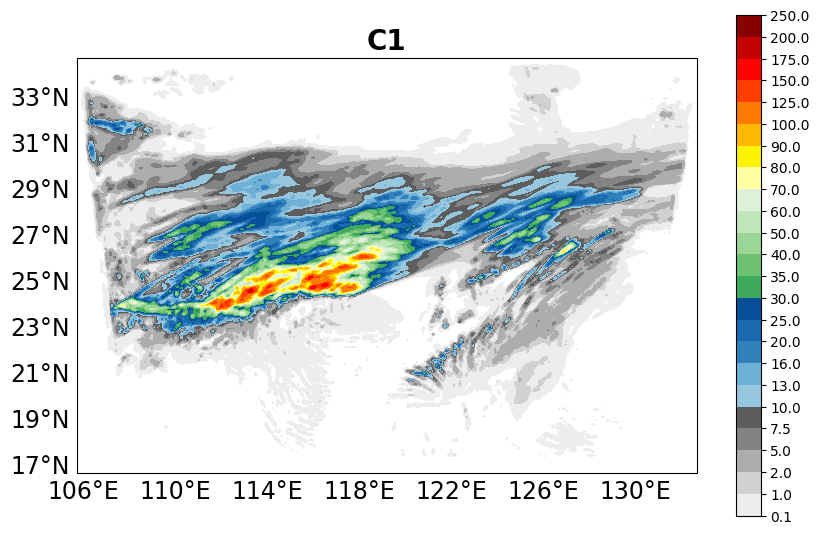

In [7]:
# 画图
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
contour = ax.contourf(lon,lat, R, clevs, colors=clors, transform=ccrs.PlateCarree())
cb_cf = fig.colorbar(contour, ax=ax,ticks=clevs, shrink=.65)

g1=ax.gridlines(draw_labels=True,linewidth=1,color='none',alpha=0.5,linestyle='--',x_inline=False,y_inline=False)
g1.top_labels=False
g1.right_labels=False
g1.xformatter=LONGITUDE_FORMATTER
g1.yformatter=LATITUDE_FORMATTER
g1.rotate_labels=False
g1.xlocator = mticker.FixedLocator(np.arange(60,140,1))
g1.ylocator = mticker.FixedLocator(np.arange(10,60,1))
g1.xlabel_style={'size':17}
g1.ylabel_style={'size':17}
plt.title('C1', fontsize=20, fontweight='bold')

ax.add_geometries(countries.geometries(),linewidth=.5,edgecolor='black',crs=ccrs.PlateCarree(),facecolor='none') 
ax.add_geometries(ten.geometries(),linewidth=.5,edgecolor='black',crs=ccrs.PlateCarree(),facecolor='none') 
ax.add_geometries(province.geometries(),linewidth=.5,edgecolor='black',crs=ccrs.PlateCarree(),facecolor='none') 
ax.set_extent([115.5,120.5,23.5,28.5],crs=ccrs.PlateCarree()) # 小范围D03
#fujian=BasicReader(r"C:/Users/xmxm/Desktop/slt/fujian.shp", encoding='gbk')
#ax.add_geometries(fujian.geometries(),linewidth=.5,edgecolor='black',crs=ccrs.PlateCarree(),facecolor='none')
#ax.set_extent([60,140,10,60],crs=ccrs.PlateCarree()) # 全国
